# AG News Text Classification using Classical Machine Learning and Transformer Models

## Project Overview

The goal of this project is to classify news articles into one of four categories:
- World
- Sports
- Business
- Sci/Tech

We compare a traditional machine learning approach based on TF-IDF and Logistic Regression with a modern Transformer-based architecture (DistilBERT).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import evaluate

In [2]:
dataset = load_dataset("ag_news")

dataset

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

# Dataset Exploration

In [3]:
for i in range(5):
    print(dataset["train"][i])
    print()

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}

{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}

{'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}

{'text': 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.', '

# Class names

In [4]:
labels = ["World", "Sports", "Business", "Sci/Tech"]
print(labels)

['World', 'Sports', 'Business', 'Sci/Tech']


# Class distribution plot

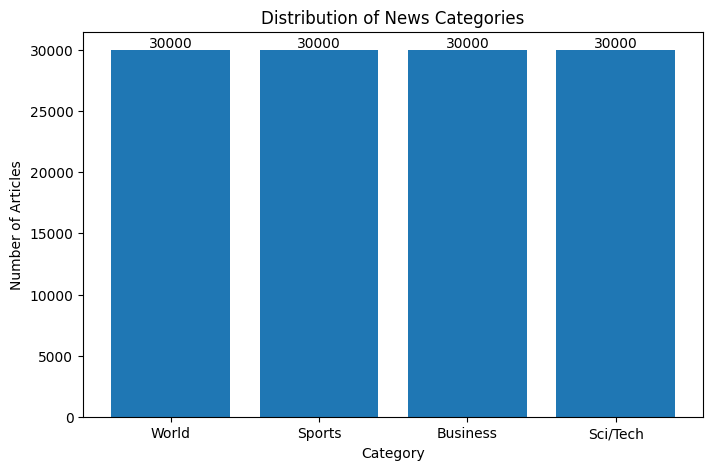

In [7]:
labels = ["World", "Sports", "Business", "Sci/Tech"]

train_labels = dataset["train"]["label"]

counts = [train_labels.count(i) for i in range(4)]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, counts)

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 200,
        f"{height}",
        ha='center'
    )

plt.show()

The AG News dataset is balanced across all four categories, with approximately the same number of training samples per class. This is in our advantage because it reduces class imbalance issues during model training.

## Text Preprocessing

Before training the models, the text data had to be transformed into a numerical format that machine learning algorithms can work with.

For the classical machine learning baseline, TF-IDF vectorization was used. TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical vectors based on how important words are inside a document compared to the entire dataset. Common words receive lower importance, while more informative words receive higher weights.

For the Transformer-based approach, the DistilBERT tokenizer was used. Unlike TF-IDF, Transformer tokenization preserves contextual information and converts text into token IDs that can be processed by the pretrained neural network architecture.

The text was also truncated and padded to ensure a consistent input size during training.

# Baseline Model - Logistic Regression

In [8]:
train_texts = dataset["train"]["text"][:5000]
train_labels = dataset["train"]["label"][:5000]

test_texts = dataset["test"]["text"][:1000]
test_labels = dataset["test"]["label"][:1000]

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, train_labels)

lr_preds = lr_model.predict(X_test)

lr_acc = accuracy_score(test_labels, lr_preds)

print("Accuracy:", lr_acc)

Accuracy: 0.856


# Classification Report

In [9]:
print(classification_report(test_labels, lr_preds))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       268
           1       0.92      0.93      0.93       274
           2       0.82      0.74      0.78       205
           3       0.79      0.88      0.83       253

    accuracy                           0.86      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.86      0.86      0.86      1000



# Confusion Matrix

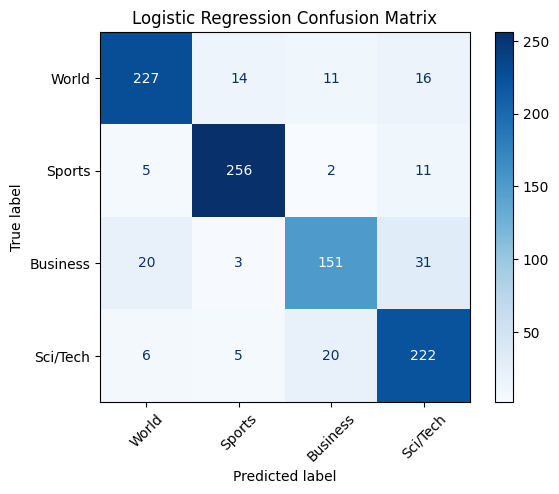

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Transformer Model

## Transformer Based Models for Text Classification

Recent advances in Natural Language Processing have shown that Transformer based architectures significantly outperform traditional machine learning methods on text classification benchmarks such as AG News.

Models like BERT, XLNet and DistilBERT achieve strong performance due to their ability to capture contextual semantic relationships between words.

In this project, I selected DistilBERT because it provides a good balance between computational efficiency and classification accuracy.

In [13]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [14]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True
    )

In [15]:
small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

In [16]:
tokenized_train = small_train.map(tokenize, batched=True)
tokenized_test = small_test.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_steps=50
)

c:\Users\emino\miniconda3\envs\ds_env\Lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


The DistilBERT model was trained for one epoch because of its computational constraints, while still allowing us to evaluate the Transformer based approach.

Trainer

In [19]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# Train

In [20]:
trainer.train()

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\emino\miniconda3\envs\ds_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.8523, 'grad_norm': 17.432037353515625, 'learning_rate': 4e-05, 'epoch': 0.2}
{'loss': 0.3704, 'grad_norm': 4.431277275085449, 'learning_rate': 3e-05, 'epoch': 0.4}
{'loss': 0.4171, 'grad_norm': 12.517494201660156, 'learning_rate': 2e-05, 'epoch': 0.6}
{'loss': 0.3999, 'grad_norm': 1.491234540939331, 'learning_rate': 1e-05, 'epoch': 0.8}
{'loss': 0.382, 'grad_norm': 14.473087310791016, 'learning_rate': 0.0, 'epoch': 1.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.4065912067890167, 'eval_accuracy': 0.878, 'eval_runtime': 82.0924, 'eval_samples_per_second': 6.091, 'eval_steps_per_second': 0.767, 'epoch': 1.0}
{'train_runtime': 1182.2466, 'train_samples_per_second': 1.692, 'train_steps_per_second': 0.211, 'train_loss': 0.48434483337402345, 'epoch': 1.0}


TrainOutput(global_step=250, training_loss=0.48434483337402345, metrics={'train_runtime': 1182.2466, 'train_samples_per_second': 1.692, 'train_steps_per_second': 0.211, 'total_flos': 264944246784000.0, 'train_loss': 0.48434483337402345, 'epoch': 1.0})

# Evaluate

In [21]:
results = trainer.evaluate()

print(results)

c:\Users\emino\miniconda3\envs\ds_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.4065912067890167, 'eval_accuracy': 0.878, 'eval_runtime': 39.6016, 'eval_samples_per_second': 12.626, 'eval_steps_per_second': 1.591, 'epoch': 1.0}


c:\Users\emino\miniconda3\envs\ds_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/63 [00:00<?, ?it/s]

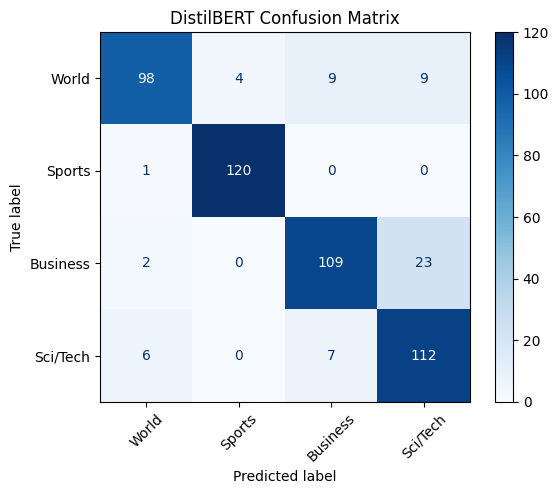

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Generate predictions
predictions = trainer.predict(tokenized_test)

preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Confusion matrix
cm = confusion_matrix(true_labels, preds)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("DistilBERT Confusion Matrix")

plt.show()

# Results Comparison Table

In [22]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DistilBERT"],
    "Accuracy": [
        lr_acc,
        results["eval_accuracy"]
    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.856
1,DistilBERT,0.878


# Example Predictions

In [23]:
sample_texts = [
    "NASA launches a new satellite into orbit",
    "Manchester United wins the final match",
    "Stock markets rise after economic report"
]

inputs = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

outputs = model(**inputs)

preds = outputs.logits.argmax(dim=1)

for text, pred in zip(sample_texts, preds):
    print(text)
    print("Prediction:", labels[pred])
    print()

NASA launches a new satellite into orbit
Prediction: Sci/Tech

Manchester United wins the final match
Prediction: Sports

Stock markets rise after economic report
Prediction: Business



# Conclusions

-Logistic Regression provided a strong classical baseline

-DistilBERT achieved higher accuracy thanks to its contextual understanding

-Transformer based architectures are highly effective for NLP classification tasks

-Future work could include larger models and hyperparameter tuning